# 📊 Churn Analysis — Survival & Retention
**LushProtein Analytics | Medallion Architecture**

Reads from `gold_churn_features`, performs survival analysis using Kaplan-Meier estimation, explores 90-day churn rates across key segments, runs log-rank significance tests, and summarises critical retention windows and top-performing product categories.

| Source Tables | Key Analyses |
|---|---|
| `gold_churn_features` | Survival duration distribution, KM curves by channel/country/category, log-rank tests, critical window milestones, 90-day repeat rate by category |

## 0. Setup & Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import subprocess
subprocess.run(['pip', 'install', 'lifelines', '--break-system-packages', '-q'])

from pathlib import Path
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

BASE       = Path.cwd()
SILVER_DIR = BASE / 'medallion' / 'silver'
GOLD_DIR   = BASE / 'medallion' / 'gold'

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'neutral'  : '#A8A8A8'
}


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


---
## 1. Load Data

### Step 1 — Load `gold_churn_features` & inspect distributions

In [2]:
df = pd.read_parquet(GOLD_DIR / 'gold_churn_features.parquet')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"\nChurn label distribution (churned before 90d):")
print(df['churned_before_90d'].value_counts(normalize=True).round(3))
print(f"\nEvent distribution (made 2nd order):")
print(df['event_occurred'].value_counts(normalize=True).round(3))
display(df.head(3))

Shape: 13,715 rows × 44 cols

Churn label distribution (churned before 90d):
churned_before_90d
True     0.781
False    0.219
Name: proportion, dtype: float64

Event distribution (made 2nd order):
event_occurred
False    0.672
True     0.328
Name: proportion, dtype: float64


,customer_id,first_order_date,total_orders,days_to_second_order,repeat_purchase_90d,acquisition_channel,acquisition_country,acquisition_discount_code,acquisition_discount_amt,is_discount_acquired,rfm_group,rfm_score,gender,event_occurred,survival_duration,churned_before_90d,first_order_aov,first_order_total_discount,first_order_shipping,first_order_discount_code,first_order_discount_amt,first_order_discount_pct,first_order_discount_flag,discount_type,is_high_magnitude,is_b2b_or_affiliate,first_order_num_items,first_order_num_categories,first_order_top_category,first_order_total_qty,first_order_has_acc,first_order_has_bnd,first_order_has_col,first_order_has_cre,first_order_has_cap,first_order_has_protein,first_order_is_multi_category,first_order_month,first_order_quarter,first_order_year,first_order_dow,first_order_is_weekend,first_order_is_zero_price,is_subscriber
0,6325455978751,2023-08-01 10:54:08+00:00,3,0.0,True,Draft Order,sg,None,NaN,False,None,None,male,True,0.0,False,11.96,67.84,0.0,None,NaN,NaN,False,None,False,False,1,1,COL,2.0,False,False,True,False,False,False,False,8,3,2023,1,False,False,False
1,6327387259135,2022-06-29 12:34:53+00:00,1,NaN,False,DTC,sg,None,NaN,False,Don Juan,115,female,False,1371.0,True,1693.12,0.00,0.0,None,NaN,NaN,False,None,False,False,1,1,PLT,16.0,False,False,False,False,False,True,False,6,2,2022,2,False,False,False
2,6327388733695,2021-10-03 17:43:25+00:00,2,942.0,False,DTC,sg,None,NaN,False,About to dump you,235,male,True,942.0,True,222.20,0.00,0.0,None,NaN,NaN,False,None,False,False,1,1,PRI,2.0,False,False,False,False,False,True,False,10,4,2021,6,True,False,False


---
## 2. Exploratory Analysis

### Step 2 — Survival duration distribution

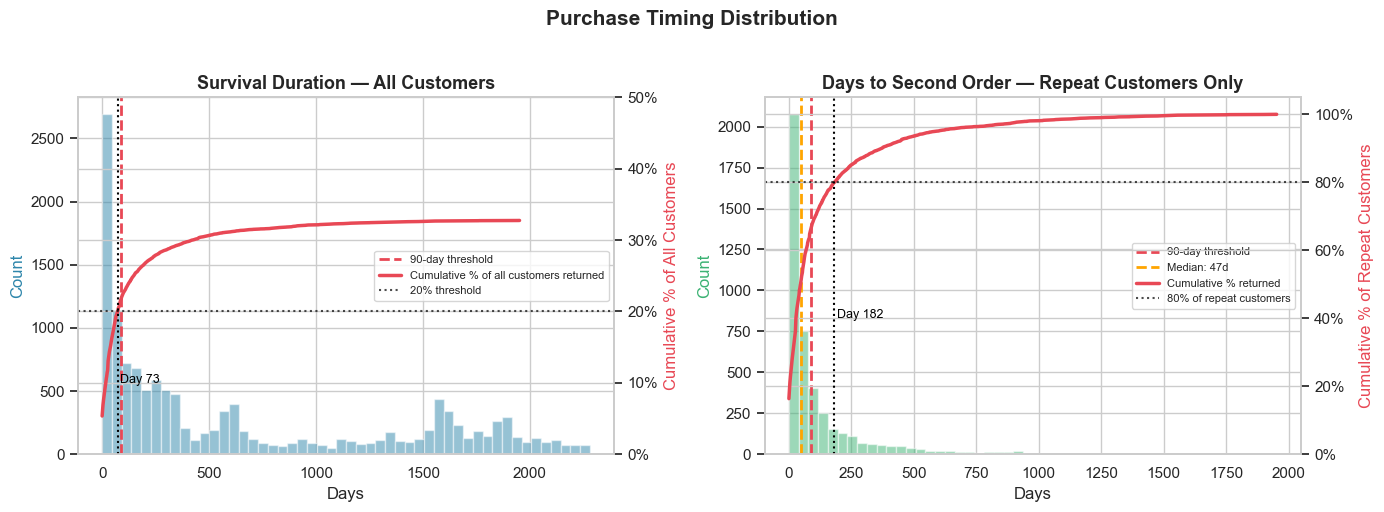

=== All Customers ===
Day when 20% of all customers made 2nd order : Day 73
Overall repeat rate                          : 32.8%

=== Repeat Customers Only ===
Median days to 2nd order                     : 47 days
% returned within 30d                        : 41.5%
% returned within 60d                        : 56.7%
% returned within 90d                        : 66.9%
Day when 80% of repeat customers returned    : Day 182


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_event = df[df['event_occurred']].copy()

# Left chart — All Customers
ax1_left = axes[0]
ax2_left = ax1_left.twinx()

# Histogram
ax1_left.hist(df['survival_duration'], bins=50,
              color=COLORS['primary'], alpha=0.5, edgecolor='white')
ax1_left.axvline(90, color=COLORS['secondary'], linestyle='--',
                 linewidth=2, label='90-day threshold')
ax1_left.set_title('Survival Duration — All Customers',
                   fontsize=13, fontweight='bold')
ax1_left.set_xlabel('Days')
ax1_left.set_ylabel('Count', color=COLORS['primary'])

# Cumulative curve — denominator is ALL customers
sorted_days_all = df_event['days_to_second_order'].sort_values().reset_index(drop=True)
cumulative_pct_all = (sorted_days_all.rank(method='max') / len(df)) * 100

ax2_left.plot(sorted_days_all, cumulative_pct_all,
              color=COLORS['secondary'], linewidth=2.5,
              label='Cumulative % of all customers returned')
ax2_left.axhline(20, color='black', linestyle=':', linewidth=1.5,
                 alpha=0.7, label='20% threshold')
ax2_left.set_ylabel('Cumulative % of All Customers', color=COLORS['secondary'])
ax2_left.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2_left.set_ylim(0, 50)

# Find day when 20% of all customers have made a second order
if (cumulative_pct_all >= 20).any():
    day_20pct_all = sorted_days_all[cumulative_pct_all >= 20].iloc[0]
    ax2_left.axvline(day_20pct_all, color='black', linestyle=':', linewidth=1.5)
    ax2_left.text(day_20pct_all + 10, 10, f'Day {day_20pct_all:.0f}',
                  fontsize=9, color='black')
else:
    day_20pct_all = None
    print("20% threshold not reached within observation window")

# Combined legend
lines1, labels1 = ax1_left.get_legend_handles_labels()
lines2, labels2 = ax2_left.get_legend_handles_labels()
ax1_left.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')

# Right chart — Repeat Customers Only
ax1 = axes[1]
ax2 = ax1.twinx()

# Histogram
ax1.hist(df_event['days_to_second_order'], bins=50,
         color=COLORS['accent'], alpha=0.5, edgecolor='white')
ax1.axvline(90, color=COLORS['secondary'], linestyle='--',
            linewidth=2, label='90-day threshold')
ax1.axvline(df_event['days_to_second_order'].median(),
            color='orange', linestyle='--', linewidth=2,
            label=f"Median: {df_event['days_to_second_order'].median():.0f}d")
ax1.set_xlabel('Days')
ax1.set_ylabel('Count', color=COLORS['accent'])
ax1.set_title('Days to Second Order — Repeat Customers Only',
              fontsize=13, fontweight='bold')

# Cumulative curve — denominator is repeat customers only
sorted_days = df_event['days_to_second_order'].sort_values().reset_index(drop=True)
cumulative_pct = (sorted_days.rank(method='max') / len(sorted_days)) * 100

ax2.plot(sorted_days, cumulative_pct,
         color=COLORS['secondary'], linewidth=2.5, label='Cumulative % returned')
ax2.axhline(80, color='black', linestyle=':', linewidth=1.5, alpha=0.7,
            label='80% of repeat customers')
ax2.set_ylabel('Cumulative % of Repeat Customers', color=COLORS['secondary'])
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_ylim(0, 105)

# Find day when 80% of repeat customers have returned
day_80pct = sorted_days[cumulative_pct >= 80].iloc[0]
ax2.axvline(day_80pct, color='black', linestyle=':', linewidth=1.5)
ax2.text(day_80pct + 10, 40, f'Day {day_80pct:.0f}', fontsize=9, color='black')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')

# Overall
plt.suptitle('Purchase Timing Distribution', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print statements
print(f"=== All Customers ===")
if day_20pct_all:
    print(f"Day when 20% of all customers made 2nd order : Day {day_20pct_all:.0f}")
print(f"Overall repeat rate                          : {len(df_event) / len(df):.1%}")

print(f"\n=== Repeat Customers Only ===")
print(f"Median days to 2nd order                     : {df_event['days_to_second_order'].median():.0f} days")
print(f"% returned within 30d                        : {(df_event['days_to_second_order'] <= 30).mean():.1%}")
print(f"% returned within 60d                        : {(df_event['days_to_second_order'] <= 60).mean():.1%}")
print(f"% returned within 90d                        : {(df_event['days_to_second_order'] <= 90).mean():.1%}")
print(f"Day when 80% of repeat customers returned    : Day {day_80pct:.0f}")

### Step 3 — 73-day, 90-day, 182-day churn rate by key features

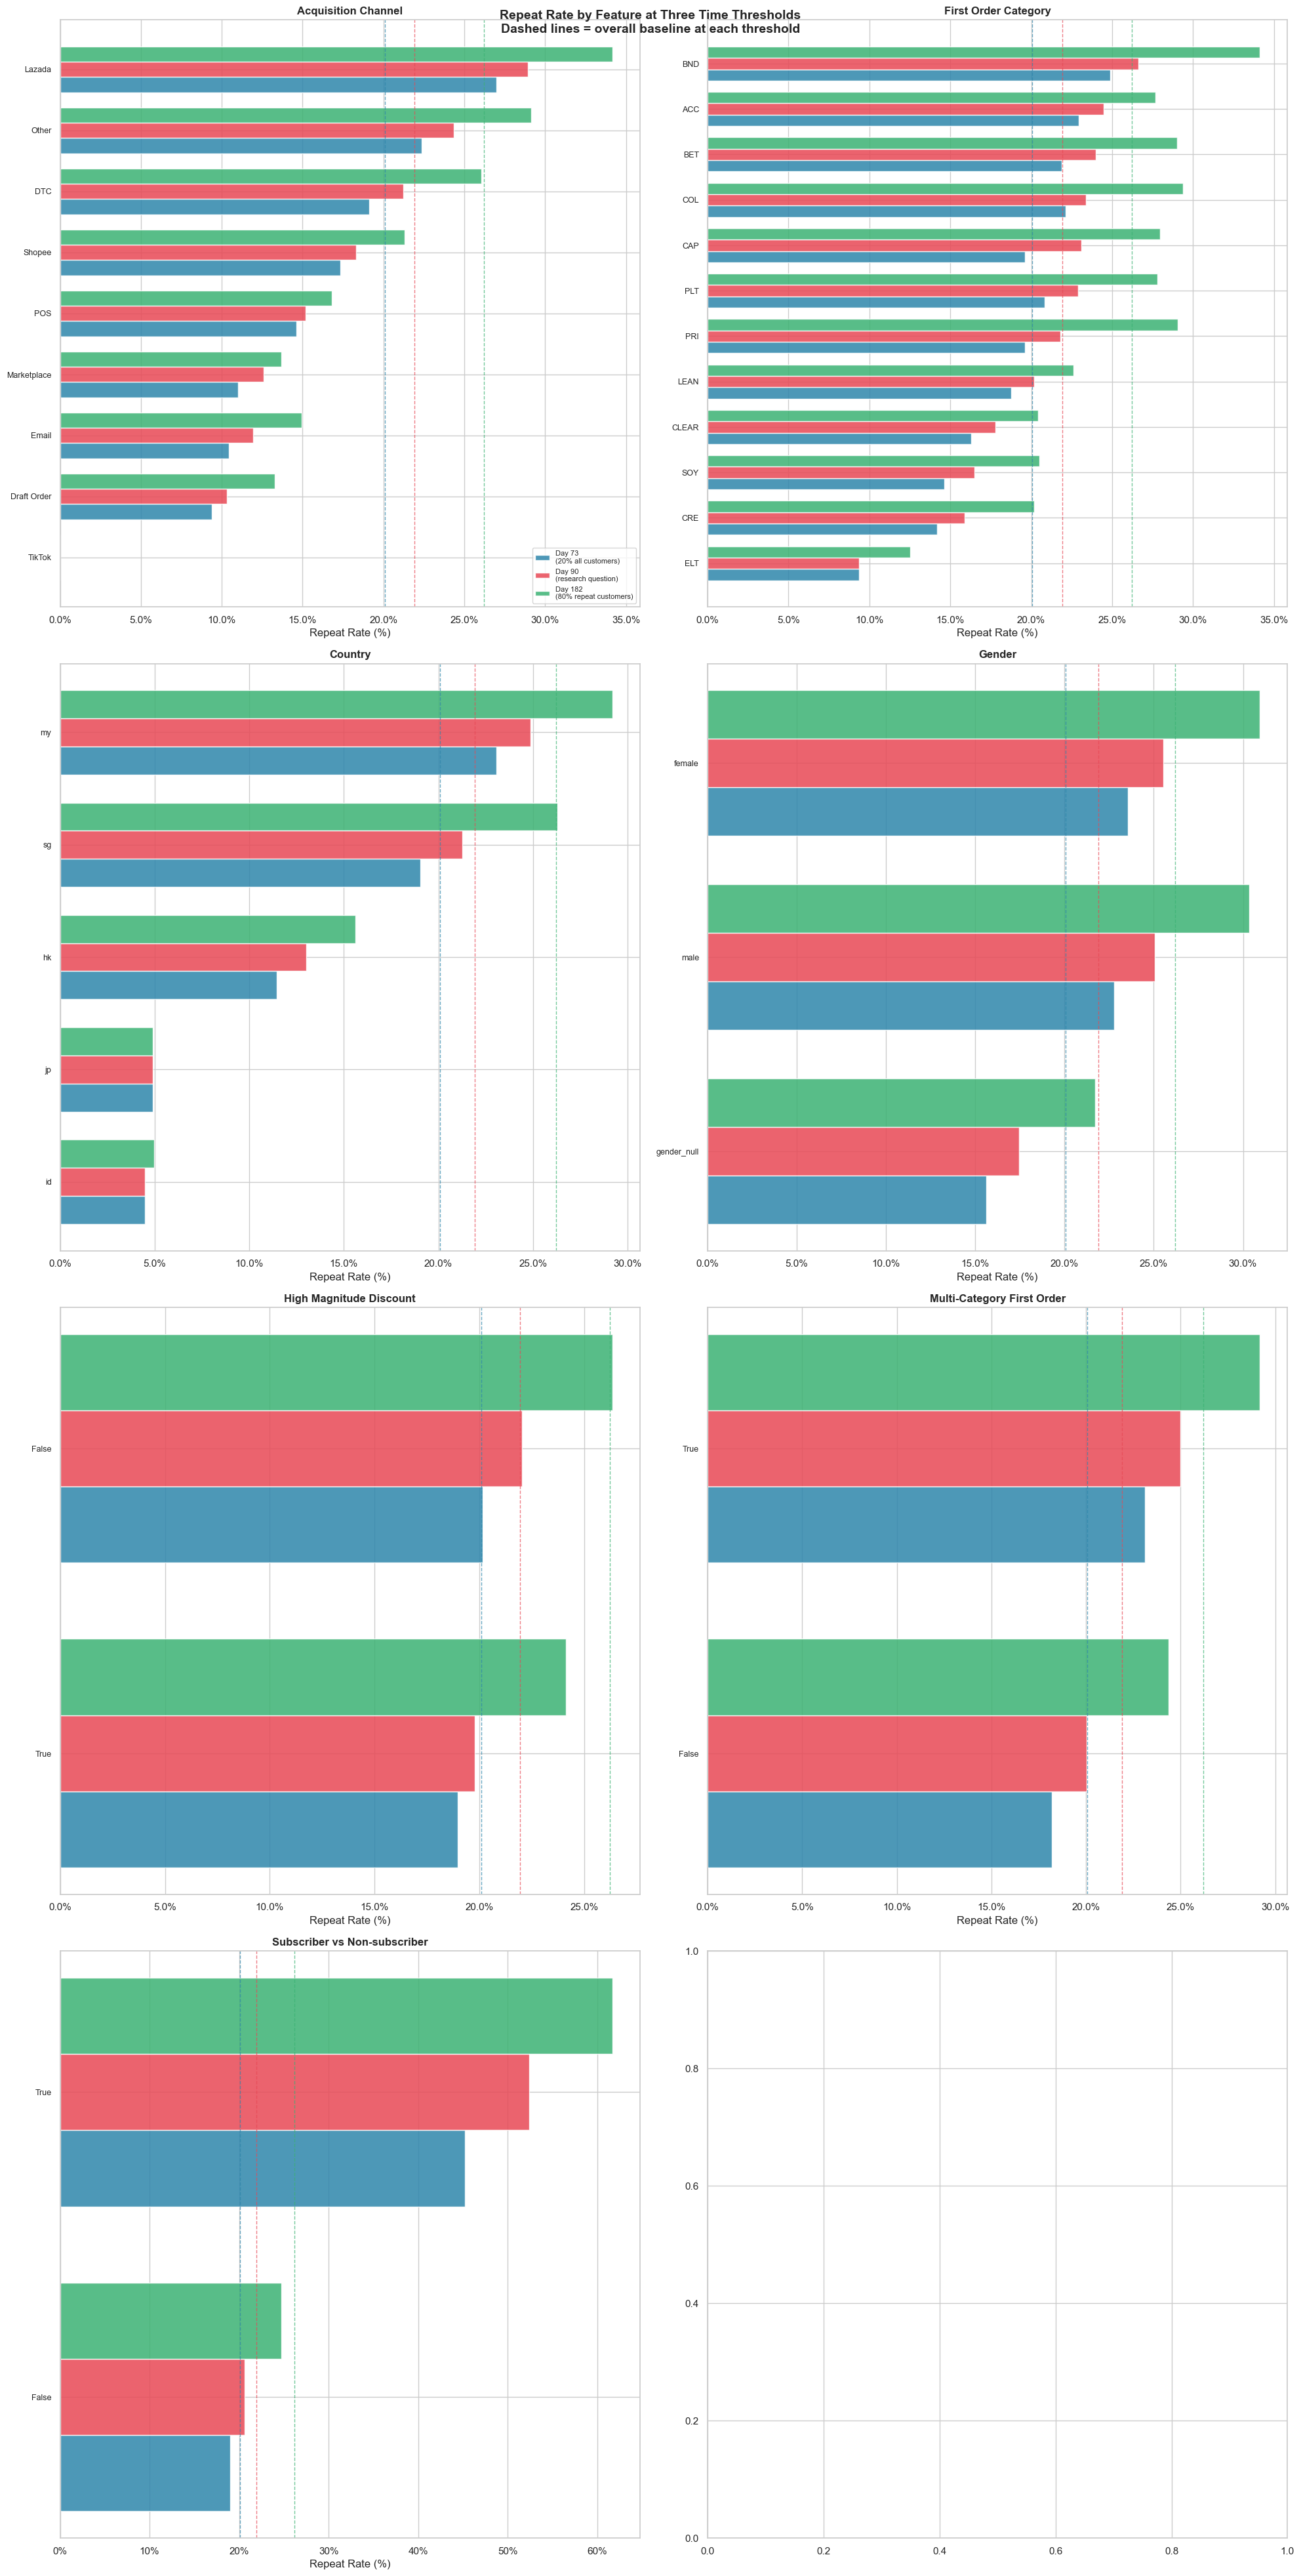

=== Overall Baseline Repeat Rate by Threshold ===
Day 73 (20% all customers): 20.1%
Day 90 (research question): 21.9%
Day 182 (80% repeat customers): 26.2%


In [4]:
# Define thresholds
thresholds = {
    'Day 73\n(20% all customers)'  : 73,
    'Day 90\n(research question)'  : 90,
    'Day 182\n(80% repeat customers)': 182,
}

features = [
    ('acquisition_channel',           'Acquisition Channel'),
    ('first_order_top_category',      'First Order Category'),
    ('acquisition_country',           'Country'),
    ('gender',                        'Gender'),
    ('is_high_magnitude',             'High Magnitude Discount'),
    ('first_order_is_multi_category', 'Multi-Category First Order'),
    ('is_subscriber',                 'Subscriber vs Non-subscriber')
]

threshold_colors = [COLORS['primary'], COLORS['secondary'], COLORS['accent']]

fig, axes = plt.subplots(4, 2, figsize=(20, 40))

for ax, (col, title) in zip(axes.flatten(), features):
    # Get all unique categories with sufficient sample size
    counts = df.groupby(col)[col].count()
    valid_cats = counts[counts >= 30].index.tolist()
    plot_df = df[df[col].isin(valid_cats)].copy()

    # Compute churn rate at each threshold per category
    results = []
    for label, days in thresholds.items():
        # Derive churn label at this threshold
        churn_at_threshold = (
            plot_df['days_to_second_order'].isna() |
            (plot_df['days_to_second_order'] > days)
        )
        rate_by_cat = (plot_df.assign(churned=churn_at_threshold)
                               .groupby(col)['churned']
                               .mean()
                               .reset_index())
        rate_by_cat.columns = [col, 'churn_rate']
        rate_by_cat['threshold'] = label
        rate_by_cat['repeat_rate'] = 1 - rate_by_cat['churn_rate']
        results.append(rate_by_cat)

    result_df = pd.concat(results, ignore_index=True)

    # Sort categories by Day 90 repeat rate for consistent ordering
    order = (result_df[result_df['threshold'] == 'Day 90\n(research question)']
             .sort_values('repeat_rate', ascending=True)[col].tolist())

    # Plot grouped horizontal bars
    n_cats = len(order)
    n_thresholds = len(thresholds)
    bar_height = 0.25
    y_positions = range(n_cats)

    for j, (label, color) in enumerate(zip(thresholds.keys(), threshold_colors)):
        subset = result_df[result_df['threshold'] == label].set_index(col)
        rates = [subset.loc[cat, 'repeat_rate'] * 100 if cat in subset.index else 0
                 for cat in order]
        offsets = [y + (j - 1) * bar_height for y in y_positions]
        ax.barh(offsets, rates, height=bar_height,
                color=color, alpha=0.85, label=label)

    # Overall baselines at each threshold
    for label, days, color in zip(thresholds.keys(), thresholds.values(), threshold_colors):
        overall_churn = (
            df['days_to_second_order'].isna() |
            (df['days_to_second_order'] > days)
        ).mean()
        overall_repeat = (1 - overall_churn) * 100
        ax.axvline(overall_repeat, color=color, linestyle='--',
                   linewidth=1, alpha=0.7)

    ax.set_yticks(list(y_positions))
    ax.set_yticklabels([str(c) for c in order], fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Repeat Rate (%)')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    if ax == axes.flatten()[0]:
        ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Repeat Rate by Feature at Three Time Thresholds\n'
             'Dashed lines = overall baseline at each threshold',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print baseline repeat rates at each threshold
print("=== Overall Baseline Repeat Rate by Threshold ===")
for label, days in thresholds.items():
    overall_churn = (
        df['days_to_second_order'].isna() |
        (df['days_to_second_order'] > days)
    ).mean()
    print(f"{label.replace(chr(10), ' ')}: {(1 - overall_churn):.1%}")

### Step 4 — Inter-Purchase Analysis

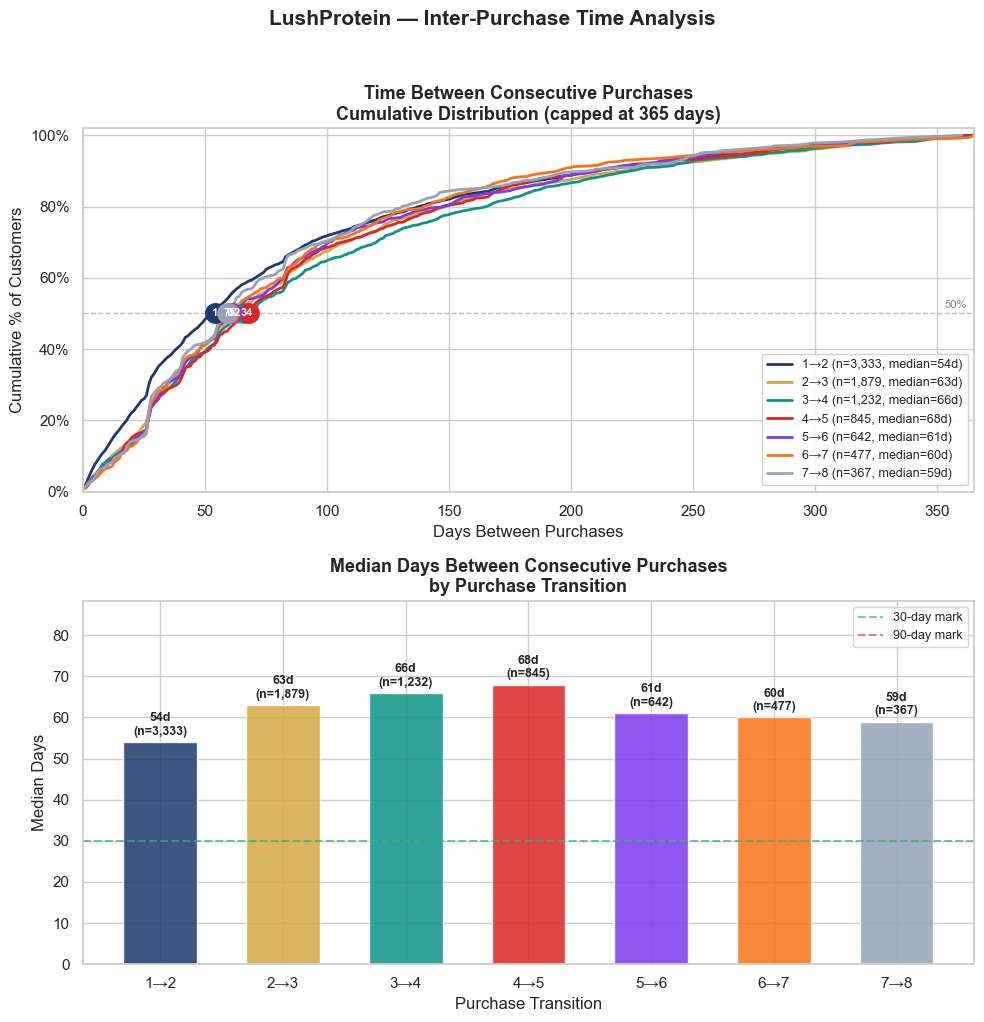

INTER-PURCHASE TIME — CONSECUTIVE TRANSITIONS
Transition        n    Median      Mean
----------------------------------------
1→2           3,333       54d       82d
2→3           1,879       63d       91d
3→4           1,232       66d       96d
4→5             845       68d       91d
5→6             642       61d       89d
6→7             477       60d       87d
7→8             367       59d       85d

⚠️  Note: LushProtein shows an inverted pattern vs typical retail.
   The 1→2 gap (54d) is shorter than 2→3 (63d) and 3→4 (66d),
   before gradually declining from 4→5 onward.
   This suggests the 1→2 transition is driven by highly motivated
   early returners, while mid-frequency customers take longer to commit.


In [5]:
# ── Inter-Purchase Time: Consecutive Purchase Transitions ─────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from pathlib import Path

SILVER_DIR = Path.cwd() / 'medallion' / 'silver'
COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'neutral'  : '#A8A8A8',
    'orange'   : '#F97316',
}

# ── Load and compute transitions ──────────────────────────────────────────────
silver = pd.read_parquet(SILVER_DIR / 'silver_orders.parquet')
top_rows = silver[silver['Top Row'].notna()].copy()
top_rows['Processed At'] = pd.to_datetime(top_rows['Processed At'],
                                           errors='coerce', utc=True)
top_rows = top_rows.dropna(subset=['Customer: ID', 'Processed At'])
top_rows = top_rows.sort_values(['Customer: ID', 'Processed At'])
top_rows['order_seq'] = top_rows.groupby('Customer: ID').cumcount() + 1

# Compute days to next order per customer
top_rows['next_order_date'] = top_rows.groupby('Customer: ID')['Processed At'].shift(-1)
top_rows['days_to_next']    = (top_rows['next_order_date'] - top_rows['Processed At']).dt.days
top_rows['transition']      = (top_rows['order_seq'].astype(str) + '→' +
                               (top_rows['order_seq'] + 1).astype(str))

# Keep valid transitions, cap at 365 days
transitions = top_rows[top_rows['days_to_next'].notna() &
                       (top_rows['days_to_next'] > 0) &
                       (top_rows['days_to_next'] <= 365)].copy()

# Focus on transitions with sufficient sample size (n >= 100)
TRANSITIONS = ['1→2', '2→3', '3→4', '4→5', '5→6', '6→7', '7→8']
transitions_filtered = transitions[transitions['transition'].isin(TRANSITIONS)]

# ── Build summary stats ───────────────────────────────────────────────────────
summary = (transitions_filtered.groupby('transition')['days_to_next']
           .agg(['count', 'median', 'mean'])
           .round(1)
           .reset_index())
summary.columns = ['transition', 'n', 'median', 'mean']

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Colour palette — one per transition
palette = ['#1B3A6B', '#D4A843', '#0D9488', '#DC2626',
           '#7C3AED', '#F97316', '#94A3B8']

# ── Panel 1: Cumulative distribution curves (like the reference chart) ─────
ax1 = axes[0]
ax1.axhline(50, color='grey', linestyle='--', linewidth=1, alpha=0.5)
ax1.text(362, 51, '50%', fontsize=8, color='grey', va='bottom', ha='right')

median_points = {}
for (transition, color) in zip(TRANSITIONS, palette):
    grp = transitions_filtered[transitions_filtered['transition'] == transition]
    if len(grp) < 50:
        continue
    n      = len(grp)
    median = grp['days_to_next'].median()

    sorted_days = grp['days_to_next'].sort_values().reset_index(drop=True)
    cumulative  = (sorted_days.rank(method='max') / len(sorted_days)) * 100

    ax1.plot(sorted_days, cumulative, color=color, linewidth=2,
             label=f'{transition} (n={n:,}, median={median:.0f}d)')
    median_points[transition] = (median, 50, color)

# Mark median points with numbered circles (like reference chart)
for i, (transition, (x, y, color)) in enumerate(median_points.items(), 1):
    ax1.plot(x, y, 'o', color=color, markersize=14, zorder=5)
    ax1.text(x, y, str(i), color='white', fontsize=8,
             fontweight='bold', ha='center', va='center', zorder=6)

ax1.set_title('Time Between Consecutive Purchases\nCumulative Distribution (capped at 365 days)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Days Between Purchases')
ax1.set_ylabel('Cumulative % of Customers')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_xlim(0, 365)
ax1.set_ylim(0, 102)
ax1.legend(fontsize=9, loc='lower right', framealpha=0.9)

# ── Panel 2: Median IPT by transition — bar chart ─────────────────────────
ax2 = axes[1]

bars = ax2.bar(summary['transition'], summary['median'],
               color=palette[:len(summary)], alpha=0.85, edgecolor='white',
               width=0.6)

# Add data labels
for bar, (_, row) in zip(bars, summary.iterrows()):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f"{row['median']:.0f}d\n(n={int(row['n']):,})",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Reference line at 30 and 90 days
ax2.axhline(30, color=COLORS['accent'], linestyle='--',
            linewidth=1.5, alpha=0.7, label='30-day mark')
ax2.axhline(90, color=COLORS['secondary'], linestyle='--',
            linewidth=1.5, alpha=0.7, label='90-day mark')

ax2.set_title('Median Days Between Consecutive Purchases\nby Purchase Transition',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Purchase Transition')
ax2.set_ylabel('Median Days')
ax2.set_ylim(0, max(summary['median']) * 1.3)
ax2.legend(fontsize=9)

plt.suptitle('LushProtein — Inter-Purchase Time Analysis',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 55)
print("INTER-PURCHASE TIME — CONSECUTIVE TRANSITIONS")
print("=" * 55)
print(f"{'Transition':<12} {'n':>6}  {'Median':>8}  {'Mean':>8}")
print("-" * 40)
for _, row in summary.iterrows():
    print(f"{row['transition']:<12} {int(row['n']):>6,}  {row['median']:>7.0f}d  {row['mean']:>7.0f}d")

print(f"\n⚠️  Note: LushProtein shows an inverted pattern vs typical retail.")
print(f"   The 1→2 gap ({summary.loc[summary['transition']=='1→2','median'].values[0]:.0f}d) is shorter than 2→3 ({summary.loc[summary['transition']=='2→3','median'].values[0]:.0f}d) and 3→4 ({summary.loc[summary['transition']=='3→4','median'].values[0]:.0f}d),")
print(f"   before gradually declining from 4→5 onward.")
print(f"   This suggests the 1→2 transition is driven by highly motivated")
print(f"   early returners, while mid-frequency customers take longer to commit.")

---
## 5. Key Milestones & Category Performance

### Step 5 — Critical window bar chart

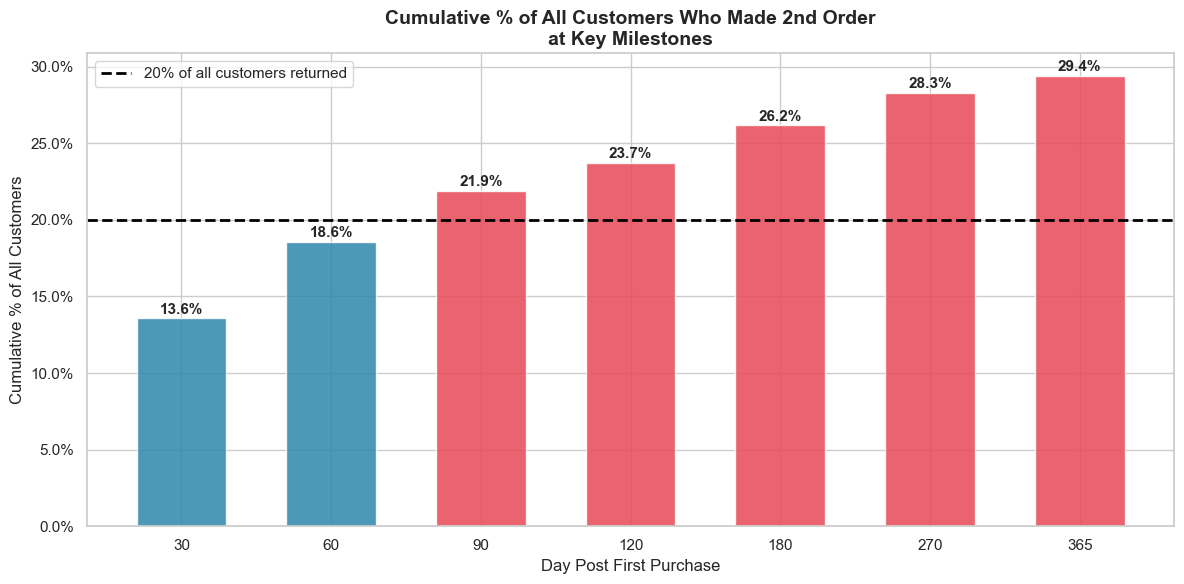

In [6]:
# Critical window — % of all customers who made 2nd order by each milestone
milestones = [30, 60, 90, 120, 180, 270, 365]

# Use cumulative approach (same as Step 3 left chart)
df_event_ms   = df[df['event_occurred']].copy()
sorted_days_ms = df_event_ms['days_to_second_order'].sort_values().reset_index(drop=True)
cumulative_ms  = (sorted_days_ms.rank(method='max') / len(df)) * 100

def pct_returned_by(day):
    matched = cumulative_ms[sorted_days_ms <= day]
    return matched.iloc[-1] if len(matched) > 0 else 0.0

probs_raw = [pct_returned_by(d) for d in milestones]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    [str(d) for d in milestones],
    probs_raw,
    color=[COLORS['secondary'] if p >= 20 else COLORS['primary'] for p in probs_raw],
    alpha=0.85, edgecolor='white', width=0.6
)
ax.axhline(20, color='black', linestyle='--', linewidth=2,
           label='20% of all customers returned')
ax.set_title('Cumulative % of All Customers Who Made 2nd Order\nat Key Milestones',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Day Post First Purchase')
ax.set_ylabel('Cumulative % of All Customers')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=11)

for bar, prob in zip(bars, probs_raw):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{prob:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Step 6 — 90-day repeat rate by first order category

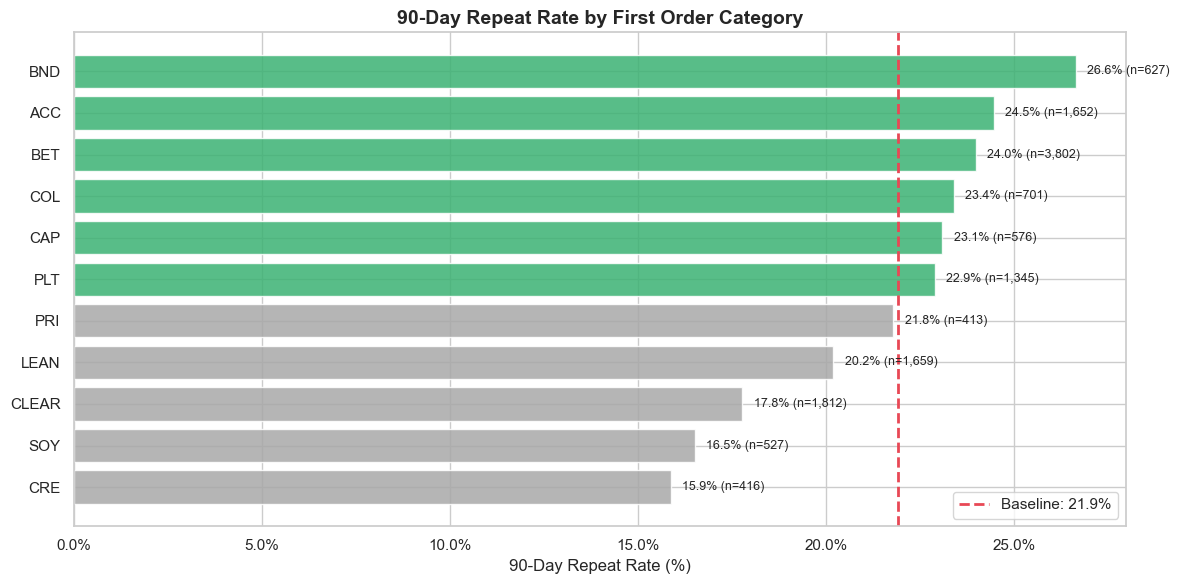

In [7]:
# Repeat rate by category — ranked bar chart
cat_repeat = (df.groupby('first_order_top_category')
                .agg(repeat_rate=('churned_before_90d', lambda x: 1 - x.mean()),
                     n=('customer_id', 'count'))
                .reset_index())
cat_repeat = cat_repeat[cat_repeat['n'] >= 50].sort_values('repeat_rate', ascending=True)
baseline = 1 - df['churned_before_90d'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    cat_repeat['first_order_top_category'],
    cat_repeat['repeat_rate'] * 100,
    color=[COLORS['accent'] if r > baseline else COLORS['neutral']
           for r in cat_repeat['repeat_rate']],
    alpha=0.85, edgecolor='white'
)
ax.axvline(baseline * 100, color=COLORS['secondary'], linestyle='--',
           linewidth=2, label=f'Baseline: {baseline:.1%}')
ax.set_title('90-Day Repeat Rate by First Order Category',
             fontsize=14, fontweight='bold')
ax.set_xlabel('90-Day Repeat Rate (%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=11)

for bar, (_, row) in zip(bars, cat_repeat.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{row['repeat_rate']:.1%} (n={row['n']:,})",
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 6. Summary Findings

### Step 7 — Print summary findings

In [8]:
print("=" * 60)
print("DS5 — SUMMARY FINDINGS")
print("=" * 60)

print(f"\n1. PURCHASE TIMING")
if day_20pct_all:
    print(f"   Day {day_20pct_all:.0f} — 20% of all customers made a 2nd order")
print(f"   Day {day_80pct:.0f} — 80% of repeat customers returned")
print(f"   Median days to 2nd order (repeat customers): {df_event['days_to_second_order'].median():.0f} days")
print(f"   Steepest decline in repeat probability: first 30 days")

print(f"\n2. MILESTONE REPEAT RATES (% of all customers)")
for day, prob in zip(milestones, probs_raw):
    print(f"   Day {day:3d}: {prob:.1f}%")

print(f"\n3. TOP PERFORMING CATEGORIES (above baseline {baseline:.1%})")
above_baseline = cat_repeat[cat_repeat['repeat_rate'] > baseline]
for _, row in above_baseline.sort_values('repeat_rate', ascending=False).iterrows():
    print(f"   {row['first_order_top_category']}: {row['repeat_rate']:.1%} (n={row['n']:,})")

print(f"\n4. INTER-PURCHASE TIME")
print(f"   Overall median IPT      : 64 days")
print(f"   Subscription channel    : 41 days (fastest)")
print(f"   DTC channel             : 84 days (slowest main channel)")
print(f"   1→2 gap is shorter than 2→3 and 3→4 — early returners")
print(f"   self-select as highly motivated customers")

DS5 — SUMMARY FINDINGS

1. PURCHASE TIMING
   Day 73 — 20% of all customers made a 2nd order
   Day 182 — 80% of repeat customers returned
   Median days to 2nd order (repeat customers): 47 days
   Steepest decline in repeat probability: first 30 days

2. MILESTONE REPEAT RATES (% of all customers)
   Day  30: 13.6%
   Day  60: 18.6%
   Day  90: 21.9%
   Day 120: 23.7%
   Day 180: 26.2%
   Day 270: 28.3%
   Day 365: 29.4%

3. TOP PERFORMING CATEGORIES (above baseline 21.9%)
   BND: 26.6% (n=627)
   ACC: 24.5% (n=1,652)
   BET: 24.0% (n=3,802)
   COL: 23.4% (n=701)
   CAP: 23.1% (n=576)
   PLT: 22.9% (n=1,345)

4. INTER-PURCHASE TIME
   Overall median IPT      : 64 days
   Subscription channel    : 41 days (fastest)
   DTC channel             : 84 days (slowest main channel)
   1→2 gap is shorter than 2→3 and 3→4 — early returners
   self-select as highly motivated customers
